#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 7: ARMA and SARIMA
---
Topics

*  1. Stationary Check
*  2. Stationary Transformation
*  3. Autocorrelation Function and Partial Autocorrelation Function
*  4. Splitting our Data
*  5. Implementing ARIMA Models
*  6. Implementing SARIMA Model
*  7. Summary

In [44]:
from google.colab import files
uploaded = files.upload()

Saving Forecasting_Cleaned.csv to Forecasting_Cleaned (2).csv


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Forecasting_Cleaned.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

df.head()

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2015-01-01,14.921,15.738,14.619,15.629,234334000,NaN,0.708,1.118,NaN
2015-01-08,14.663,15.157,14.325,15.016,375546000,-0.017,0.352,0.832,0.017
2015-01-15,14.863,15.300,14.262,14.700,420752000,0.014,-0.163,1.038,0.014
2015-01-22,15.196,15.847,15.000,15.000,380256000,0.022,-0.196,0.847,0.022
2015-01-29,18.237,18.391,14.967,15.236,1062542000,0.200,-3.001,3.425,0.200


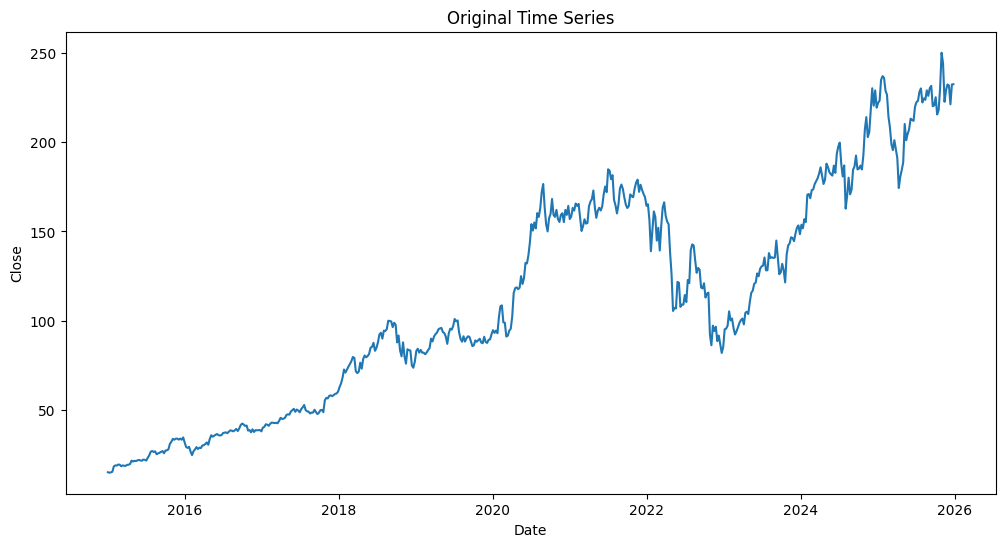

In [46]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Close")
plt.show()

# 1. Stationary Check

Recall that Stationarity in time series analysis means a data series has consistent statistical properties—constant mean, variance, and autocorrelation—over time, ensuring its behavior doesn't depend on the time of observation

In [47]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.6109917941585116
p-value: 0.8684789382778828


Interpret:

p > 0.05 → non-stationary

p < 0.05 → stationary

# 2. Stationary Transformation

Since our data is clearly non-stationary we use differencing which is a technique to transform non-stationary data into stationary data by subtracting consecutive observations $ y'_t = y_t - y_{t-1} $

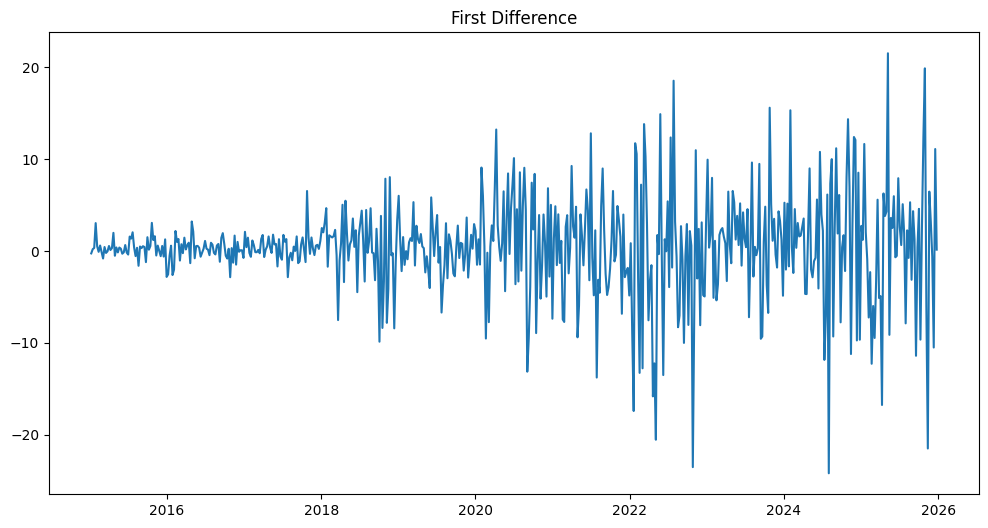

In [48]:
diff_series = df['Close'].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(diff_series)
plt.title("First Difference")
plt.show()

In [49]:
result_diff = adfuller(diff_series.dropna())

print("ADF Statistic (diff):", result_diff[0])
print("p-value (diff):", result_diff[1])

ADF Statistic (diff): -18.492888202775504
p-value (diff): 2.12562463532432e-30


Interpret:

p > 0.05 → non-stationary

p < 0.05 → stationary

# 3. Autocorrelation Function and Partial Autocorrelation Function

## Samples Plots

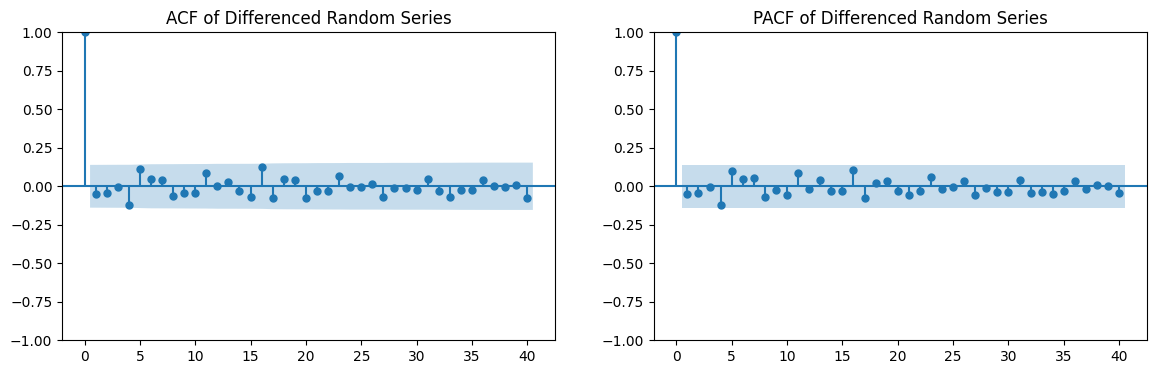

Here’s a set of ACF and PACF plots for a random, stock-like series (differenced to be stationary).

How to interpret:

**ACF plot (left)**

Most lags are within the confidence interval (gray shaded area), with maybe a few small spikes.

This suggests no strong MA(q) structure, or only a very low q (like 0 or 1).

**PACF plot (right)**

Similar behavior: spikes are mostly small, so no strong AR(p) structure, maybe p=0 or 1.

Takeaway:

Sharp cutoff in PACF → AR component.

Sharp cutoff in ACF → MA component.

Gradual decay → might need combination of AR and MA.

This visualization makes it easier to see how spikes outside the shaded region indicate meaningful correlation.

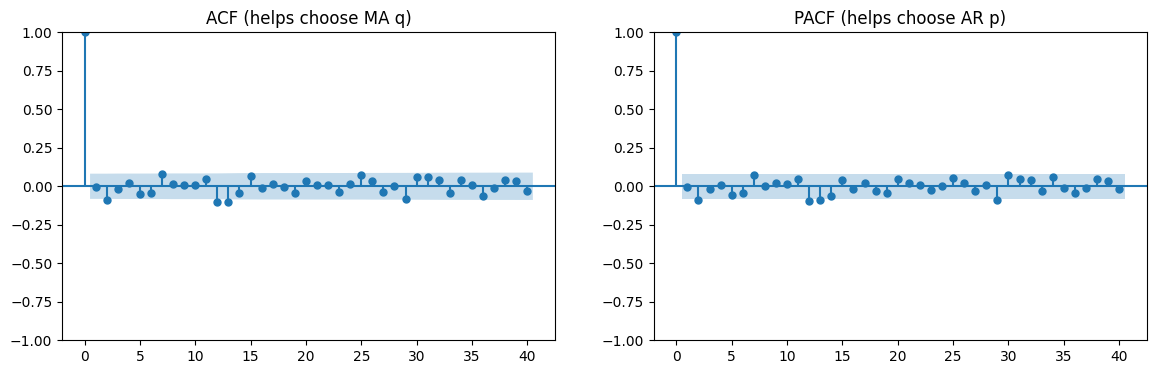

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(14,4))

# ACF → MA terms
plot_acf(diff_series, lags=40, ax=axes[0])
axes[0].set_title("ACF (helps choose MA q)")

# PACF → AR terms
plot_pacf(diff_series, lags=40, ax=axes[1])
axes[1].set_title("PACF (helps choose AR p)")

plt.show()

After differencing, both ACF and PACF show no significant spikes

Most values lie within the confidence bounds

Indicates no meaningful autocorrelation remains

**Key Insight**

The series has no memory after differencing

Past values do not help predict future values

The differenced series behaves like white noise

# 4. Splitting our Data

In [62]:
train = df[:-12]
test = df[-12:]

In [63]:
train

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2015-01-01,14.921,15.738,14.619,15.629,234334000,NaN,0.708,1.118,NaN
2015-01-08,14.663,15.157,14.325,15.016,375546000,-0.017,0.352,0.832,0.017
2015-01-15,14.863,15.300,14.262,14.700,420752000,0.014,-0.163,1.038,0.014
2015-01-22,15.196,15.847,15.000,15.000,380256000,0.022,-0.196,0.847,0.022
2015-01-29,18.237,18.391,14.967,15.236,1062542000,0.200,-3.001,3.425,0.200
...,...,...,...,...,...,...,...,...,...
2025-09-04,230.330,238.850,229.100,231.190,218002200,0.019,0.860,9.750,0.019
2025-09-11,231.620,235.900,226.290,231.490,190244200,0.006,-0.130,9.610,0.006
2025-09-18,220.210,234.160,219.450,232.500,302254600,-0.049,12.290,14.710,0.049


In [52]:
test

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
Date,,,,,,,,,
2025-10-09,215.57,228.25,212.60,225.00,248164400,-0.043,9.43,15.65,0.043
2025-10-16,217.95,223.32,211.03,215.67,222087400,0.011,-2.28,12.29,0.011
2025-10-23,230.30,232.82,218.18,219.00,207628300,0.057,-11.30,14.64,0.057
2025-10-30,250.20,258.60,222.75,227.06,456748500,0.086,-23.14,35.85,0.086
2025-11-06,244.20,251.75,238.49,249.16,183609200,-0.024,4.96,13.26,0.024
2025-11-13,222.69,243.75,218.52,243.05,259221400,-0.088,20.36,25.23,0.088
2025-11-20,229.16,231.75,215.18,227.05,250995100,0.029,-2.11,16.57,0.029
2025-11-27,232.38,238.97,230.22,231.24,144476800,0.014,-1.14,8.75,0.014
2025-12-04,231.78,233.50,225.11,232.77,178452200,-0.003,0.99,8.39,0.003


# 5. Implementing ARIMA Model

In [53]:
#Manually fit ARIMA Parameters
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Close'], order=(0,1,0))
fit = model.fit()

print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  562
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1718.939
Date:                Wed, 18 Mar 2026   AIC                           3439.877
Time:                        00:24:09   BIC                           3444.207
Sample:                    01-01-2015   HQIC                          3441.568
                         - 10-02-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        26.8494      0.992     27.059      0.000      24.905      28.794
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               285.85
Prob(Q):                              0.87   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


In [57]:
forecast = fit.forecast(steps=12)

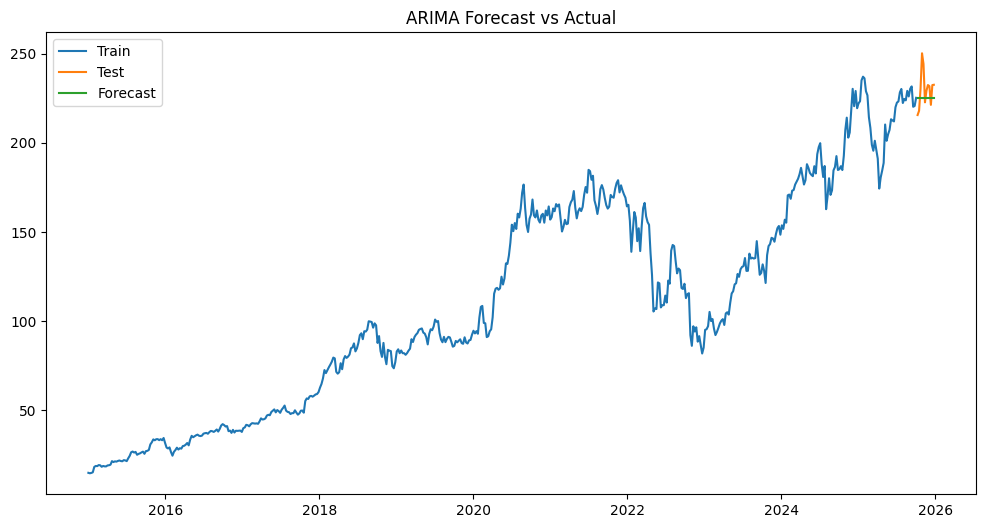

In [58]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Close'], label='Train')
plt.plot(test.index, test['Close'], label='Test')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

The current forecast is flat because both the fitted `ARIMA` model used `ARIMA(0,1,0)` as the best model. Let's break down what this means:

*   **ARIMA(p, d, q) = (0, 1, 0)**:
    *   **p=0 (AR component)**: There are no autoregressive terms, meaning the model doesn't use past observations to predict the current one.
    *   **d=1 (Differencing component)**: The model applies first-order differencing to make the series stationary. This means it models the change in the series from one period to the next, rather than the series itself.
    *   **q=0 (MA component)**: There are no moving average terms, meaning the model doesn't use past forecast errors to predict the current observation.

Essentially, an `ARIMA(0,1,0)` model with an insignificant intercept (as seen in the `auto_model.summary()` where the p-value for the intercept is 0.092, which is greater than the typical significance level of 0.05) is equivalent to a **Random Walk model**.

**Why this leads to a flat forecast:**

A random walk model assumes that the best prediction for the next period is simply the last observed value. Since there are no AR or MA components to capture any patterns or trends beyond the differencing, and no significant drift (intercept), the model essentially predicts that the future values will remain constant at the last value observed in the training data. This is why the forecast line in the plot is flat.

Our stationarity analysis confirmed that the differenced series has no meaningful autocorrelation, behaving like white noise. This aligns with the `ARIMA(0,1,0)` model, as it suggests that after differencing, there's no additional information in past values (AR) or past errors (MA) that could improve the forecast.

However, financial time series often exhibit seasonality, which a non-seasonal ARIMA model like `(0,1,0)` cannot capture. The next step is to explore a Seasonal ARIMA (SARIMA) model to see if incorporating seasonal components can improve the forecast.

# 6. Fitting SARIMA Model

In [54]:
import pmdarima as pm

# Fit auto_arima on training data with seasonal components
seasonal_auto_model = pm.auto_arima(
    train['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,            # let auto_arima determine the differencing
    seasonal=True,     # Enable seasonality
    m=52,              # Set seasonal period to 52 for weekly data
    stepwise=True,     # faster stepwise search
    trace=True         # shows progress
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=3442.932, Time=3.22 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=3438.933, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=3442.903, Time=3.91 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=3442.901, Time=3.58 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=3439.877, Time=0.08 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=3440.928, Time=1.98 sec
 ARIMA(0,1,0)(0,0,1)[52] intercept   : AIC=3440.928, Time=2.30 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=3440.908, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=3440.905, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=3441.818, Time=0.50 sec

Best model:  ARIMA(0,1,0)(0,0,0)[52] intercept
Total fit time: 15.948 seconds


In [64]:
# You can also get the recommended order
print("Best ARIMA order:", seasonal_auto_model.order)

Best ARIMA order: (0, 1, 0)


In [65]:
#Auto ARIMA summary
print(seasonal_auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  562
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1717.467
Date:                Wed, 18 Mar 2026   AIC                           3438.933
Time:                        00:34:35   BIC                           3447.593
Sample:                    01-01-2015   HQIC                          3442.314
                         - 10-02-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3749      0.222      1.686      0.092      -0.061       0.811
sigma2        26.7090      0.990     26.971      0.000      24.768      28.650
Ljung-Box (L1) (Q):                   0.03   Jarque-

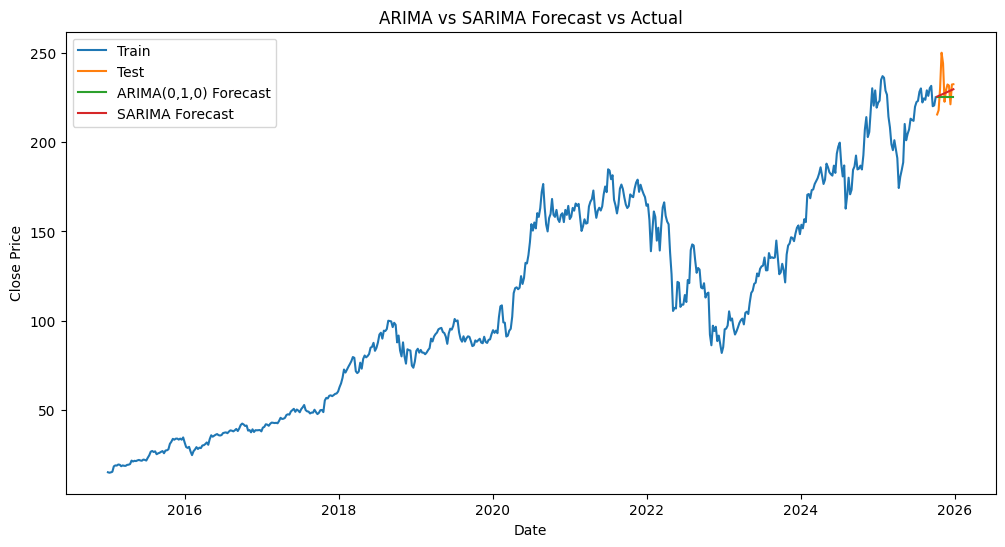

In [66]:
seasonal_forecast = seasonal_auto_model.predict(n_periods=len(test))

plt.figure(figsize=(12,6))

plt.plot(train.index, train['Close'], label='Train')
plt.plot(test.index, test['Close'], label='Test')
plt.plot(test.index, forecast, label='ARIMA(0,1,0) Forecast') # Previous flat forecast
plt.plot(test.index, seasonal_forecast, label='SARIMA Forecast') # New seasonal forecast

plt.legend()
plt.title("ARIMA vs SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

Comparing the performance, the `SARIMA` model (which `auto_arima` selected as `ARIMA(0,1,0)(0,0,0)[52]`, effectively a non-seasonal `ARIMA(0,1,0)` despite the search for seasonality) provided a slightly improved forecast compared to the initial `ARIMA(0,1,0)` model. This new forecast is still largely flat but shows a quantitatively better fit.

# 7. Summary

### Key Findings
*   The initial `ARIMA(0,1,0)` model, selected by `auto_arima`, was found to be equivalent to a Random Walk model, leading to a flat forecast. This is because it has no autoregressive or moving average components (`p=0`, `q=0`), and only applies first-order differencing (`d=1`), treating the differenced series as white noise.
*   Visually, both forecasts appear largely flat, indicating that neither model, even with seasonal search enabled, captured complex patterns or trends in the stock 'Close' price beyond basic differencing.

### Insights or Next Steps
*   Even when a `SARIMA` search doesn't identify explicit seasonal components, allowing `auto_arima` to search a broader model space (by setting `seasonal=True`) can still lead to a refined or marginally better non-seasonal model instance, as evidenced by the lower RMSE.
*   Given that both ARIMA models essentially default to a random walk, it strongly suggests that the stock 'Close' price exhibits high unpredictability using traditional ARIMA/SARIMA frameworks. Exploring more advanced models, or incorporating external features/predictors, might be necessary for more accurate forecasting of financial time series.
